In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import matplotlib.pyplot as plt


import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [3]:
import pandas as pd

In [6]:
# Importing the dataset
raw_data = pd.read_csv("credit_customers.csv",delimiter=',')
df = raw_data.copy()
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [7]:
df.dtypes # All the values seems to be in the correct format
df.isnull().sum() # Checking for null values --> We do not have any null values in the dataset
df = df.drop_duplicates() # Dropping duplicates


# Checking all the unique values from each column 
#for i in np.unique(df.columns):
    #print(df[i].unique(),'\n')
    
    
# Cleaning the values from the job column for better understanding
df['job'] = df['job'].str.replace('unskilled resident','unskilled')
df['job'] = df['job'].str.replace('high qualif/self emp/mgmt','highqualif / selfemp')
df['job'] = df['job'].str.replace('unemp/unskilled non res','unemp/unsk/ nonres')

In [8]:
df.drop(columns=['other_parties'], inplace=True)

-----

### Face 2: Data Visualization

       duration
count   1000.00
mean      20.90
std       12.06
min        4.00
25%       12.00
50%       18.00
75%       24.00
max       72.00 



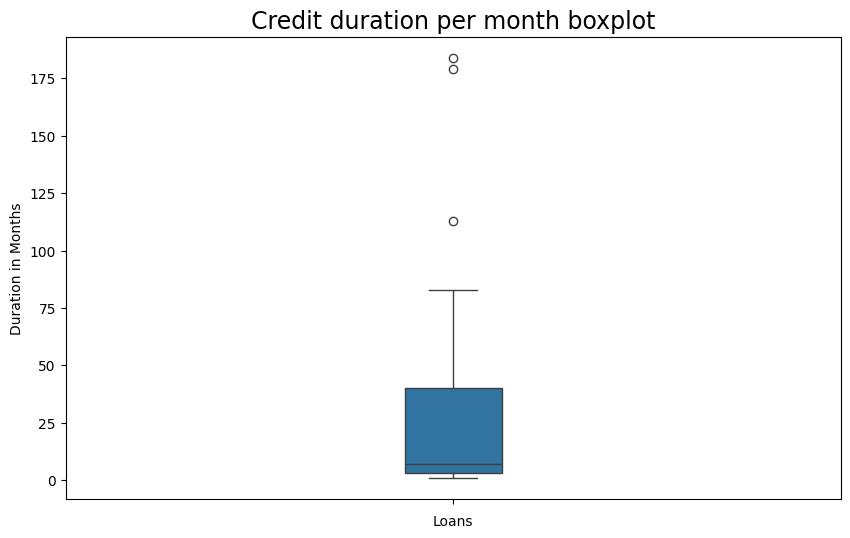



The mean loan duration is 20.9
The std loan duration is 12.06
The min loan duration is 4.0
The 25% loan duration is 12.0
The 50% loan duration is 18.0
The 75% loan duration is 24.0
The max loan duration is 72.0


In [14]:
# Getting the measures of central tendencies by duration
df_duration= df[['duration']].describe().round(2)
print(df_duration,'\n')

# Duration boxplot
df1 = df.groupby('duration')[['duration']].count()

plt.figure(figsize=(10,6))
sns.boxplot(data=df1,y=df1["duration"],width=0.125)
plt.ylabel('Duration in Months')
plt.xlabel('Loans')
plt.title('Credit duration per month boxplot', fontdict={'fontsize':'17'}, loc='center')
plt.show()

# Printing results
print('\n')
for i in range(1,len(df_duration['duration'])):
    print(f'The {df_duration.index[i]} loan duration is {df_duration.iloc[i,0]}')

## Task / Question 2: Check the loan frequencies per purpose and their weight agaist to the total amount of loans

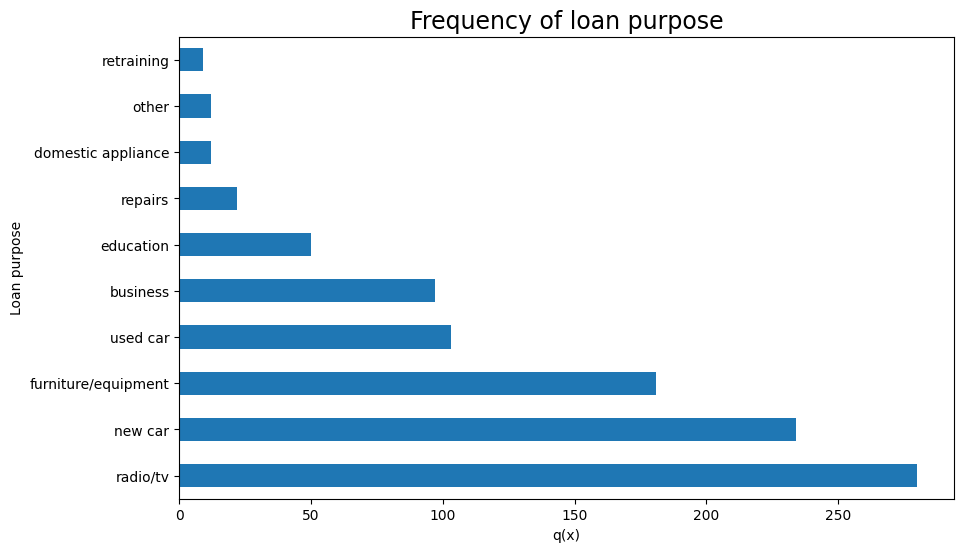

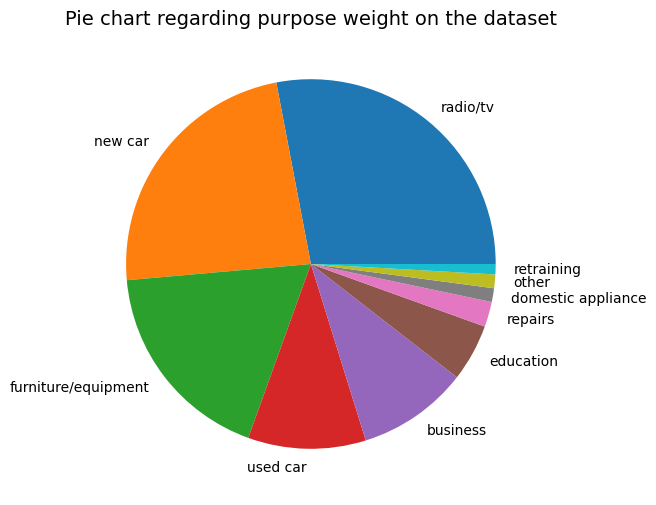


                      q(x)  Total  Weight
purpose                                 
radio/tv              280   1000    28.0
new car               234   1000    23.4
furniture/equipment   181   1000    18.1
used car              103   1000    10.3
business               97   1000     9.7
education              50   1000     5.0
repairs                22   1000     2.2
domestic appliance     12   1000     1.2
other                  12   1000     1.2
retraining              9   1000     0.9 

The purpose radio/tv represent the 28.0% from the total amount of loans
The purpose new car represent the 23.4% from the total amount of loans
The purpose furniture/equipment represent the 18.1% from the total amount of loans
The purpose used car represent the 10.3% from the total amount of loans
The purpose business represent the 9.7% from the total amount of loans
The purpose education represent the 5.0% from the total amount of loans
The purpose repairs represent the 2.2% from the total amount of

In [15]:
# Loan purpose frequency
df2 = df.groupby('purpose')[['credit_amount']].count().sort_values(by='credit_amount',ascending=False)

df2.plot(kind='barh',legend=False,figsize=(10,6))
plt.title('Frequency of loan purpose',fontdict={'fontsize':'17'}, loc='center')
plt.ylabel('Loan purpose')
plt.xlabel('q(x)')
plt.show()

# % Weight per purpose
df2 = df['purpose'].value_counts().to_frame()
df2['Total'] = 1000
df2.rename(columns={'count':'q(x)'},inplace= True)
df2['Weight'] = round((df2['q(x)']/df2['Total'])*100,2)


# Plot with labels and percentage
df2.plot(kind='pie',y='Weight', legend=None, figsize = (12,6))
plt.title('Pie chart regarding purpose weight on the dataset',fontdict={'fontsize':'14'},loc='center')
plt.show()

print('\n',df2,'\n')
for i in range(len(df2['Weight'])):
    print(f'The purpose {df2.index[i]} represent the {df2.iloc[i,2]}% from the total amount of loans')

-----

### Task / Question 3: Check the measures of central tendencies regarding Credit Amount by Purpose

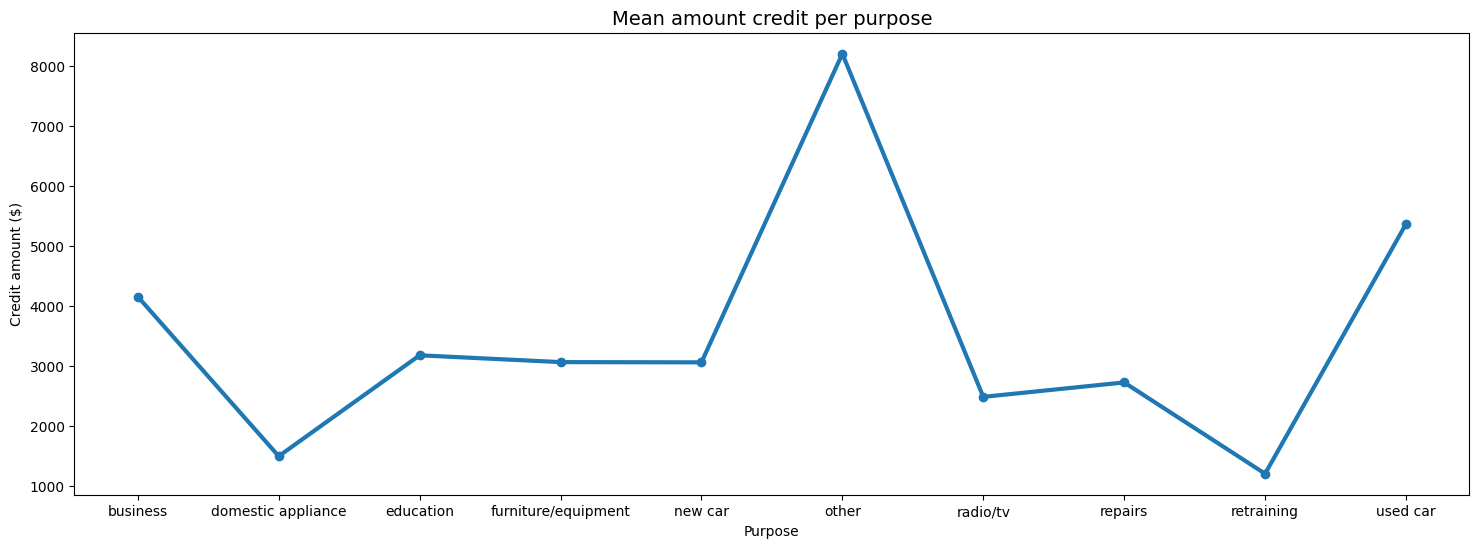



The mean credit amount taken for the purpose business is 4158.04 american dollars.
The min credit amount taken for the purpose business is 609.0 american dollars.
The max credit amount taken for the purpose business is 15945.0 american dollars.


The mean credit amount taken for the purpose domestic appliance is 1498.0 american dollars.
The min credit amount taken for the purpose domestic appliance is 343.0 american dollars.
The max credit amount taken for the purpose domestic appliance is 3990.0 american dollars.


The mean credit amount taken for the purpose education is 3180.4 american dollars.
The min credit amount taken for the purpose education is 392.0 american dollars.
The max credit amount taken for the purpose education is 12612.0 american dollars.


The mean credit amount taken for the purpose furniture/equipment is 3066.99 american dollars.
The min credit amount taken for the purpose furniture/equipment is 428.0 american dollars.
The max credit amount taken for the purpos

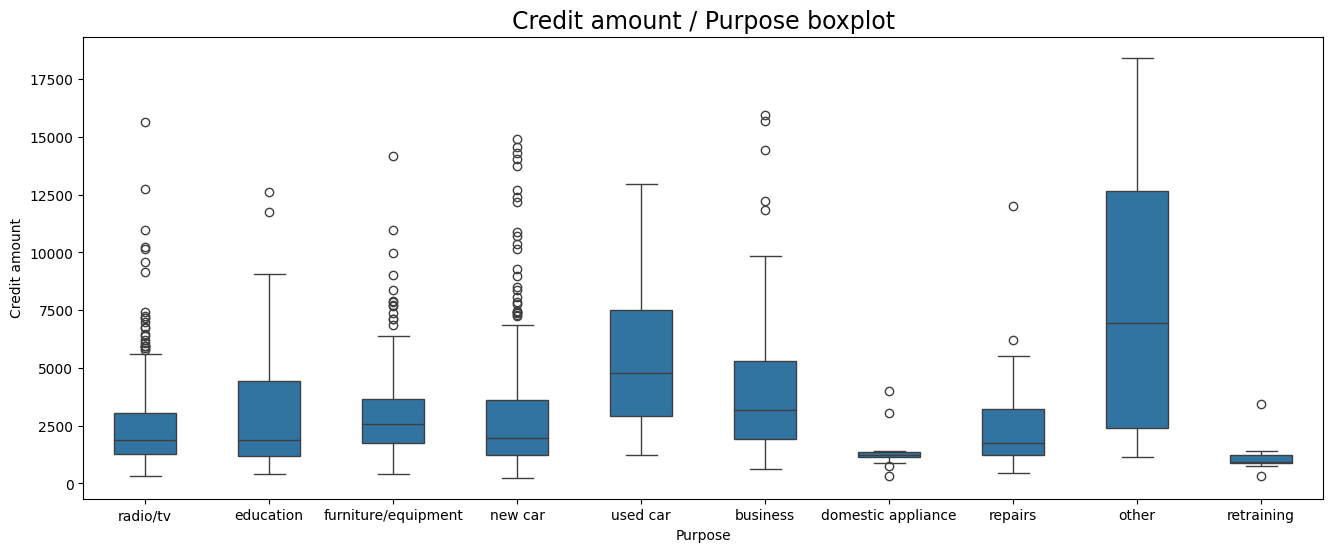

,purpose,count,mean,std,min,25%,50%,75%,max
0,business,97.0,4158.04,3231.48,609.0,1908.00,3161.0,5293.00,15945.0
1,domestic appliance,12.0,1498.00,1012.51,343.0,1131.25,1249.0,1359.50,3990.0
2,education,50.0,3180.40,3017.94,392.0,1198.25,1884.5,4425.25,12612.0
3,furniture/equipment,181.0,3066.99,2034.15,428.0,1747.00,2578.0,3643.00,14179.0
4,new car,234.0,3063.03,2962.65,250.0,1241.50,1980.0,3632.50,14896.0
5,other,12.0,8209.33,6112.70,1164.0,2410.50,6948.0,12649.00,18424.0
6,radio/tv,280.0,2487.65,2073.69,338.0,1261.00,1890.0,3038.00,15653.0
7,repairs,22.0,2728.09,2627.49,454.0,1214.50,1749.0,3203.25,11998.0
8,retraining,9.0,1205.89,891.48,339.0,894.00,932.0,1238.00,3447.0
9,used car,103.0,5370.22,2890.97,1236.0,2917.00,4788.0,7498.00,12976.0


In [16]:
# Groupping by purpose and describing credit amount column
df3 = df.groupby('purpose')['credit_amount'].describe().T.round(2)
df3

# Line chart of mean credit amount requested per purpose
df3 = df3.T.reset_index()
purpose = df3['purpose']
mean_AC = df3['mean']

plt.figure(figsize=(18,6))
plt.plot(purpose,mean_AC,linewidth=3, marker='o')
plt.xlabel('Purpose')
plt.ylabel('Credit amount ($)')
plt.title('Mean amount credit per purpose',fontdict={'fontsize':'14'},loc='center')
plt.show()

df3

# Mean, min & max credit amount taken per purpose 
print('\n')
for i in range(0,len(df3.columns)):
    print(f'The mean credit amount taken for the purpose {df3.iloc[i,0]} is {df3.iloc[i,2]} american dollars.')
    print(f'The min credit amount taken for the purpose {df3.iloc[i,0]} is {df3.iloc[i,4]} american dollars.')
    print(f'The max credit amount taken for the purpose {df3.iloc[i,0]} is {df3.iloc[i,-1]} american dollars.')
    print('\n')

# Credit amount / purpose BoxPLot
plt.figure(figsize=(16,6))
sns.boxplot(data=df,y='credit_amount',width=0.5, orient='v', x='purpose')
plt.title('Credit amount / Purpose boxplot', fontdict={'fontsize':'17'})
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.show()

print('\n')

# Central measure variable of credit amount agaisnt purpose. Min, Max, Mean, Count, std, Q1, Q3
df3

-----

### Task / Question 4: Check which group regarding employment status is the one that took more loans, and how much predominance they have on the dataset¶

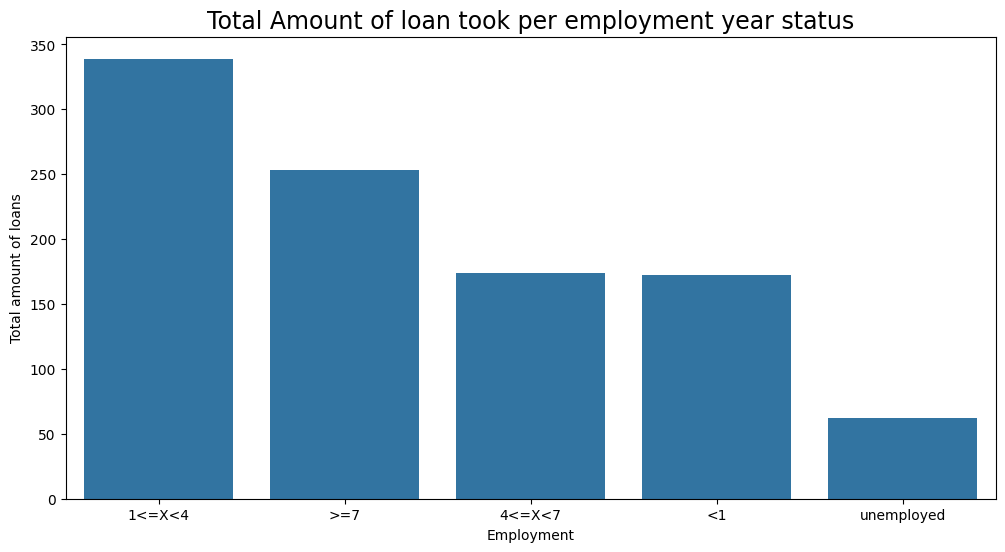

The 1<=X<4 employment group took 339 loans, they represent the 33.9 % of the dataset.
The >=7 employment group took 253 loans, they represent the 25.3 % of the dataset.
The 4<=X<7 employment group took 174 loans, they represent the 17.4 % of the dataset.
The <1 employment group took 172 loans, they represent the 17.2 % of the dataset.
The unemployed employment group took 62 loans, they represent the 6.2 % of the dataset.




In [17]:
# Groupping by employment and counting the empoyment
df5 = df.groupby('employment')['employment'].count().sort_values(ascending=False).to_frame()

# Getting the Weight (%) that each group represents on the dataset
df5['Weight'] = round((df5['employment']/ df5['employment'].sum())*100,2)
df5_str = df5.astype(str) # changing the values from int to str for printing

#Plotting a barplot regarding employment status
plt.figure(figsize=(12,6))
sns.barplot(x=df5.index,y=df5['employment'])
plt.title('Total Amount of loan took per employment year status',fontdict={'fontsize':'17'}, loc='center')
plt.xlabel('Employment')
plt.ylabel('Total amount of loans')
plt.show()

# Printing the 
for i in range(len(df5['employment'])):
    print(f'The {df5.index[i]} employment group took {df5.iloc[i,0]} loans, they represent the {df5.iloc[i,1]} % of the dataset.')

print('\n')

### Task / Question 4.1: Check the relationship between the Credit amount and Employment Status. Check the mean loan requested per employment status¶

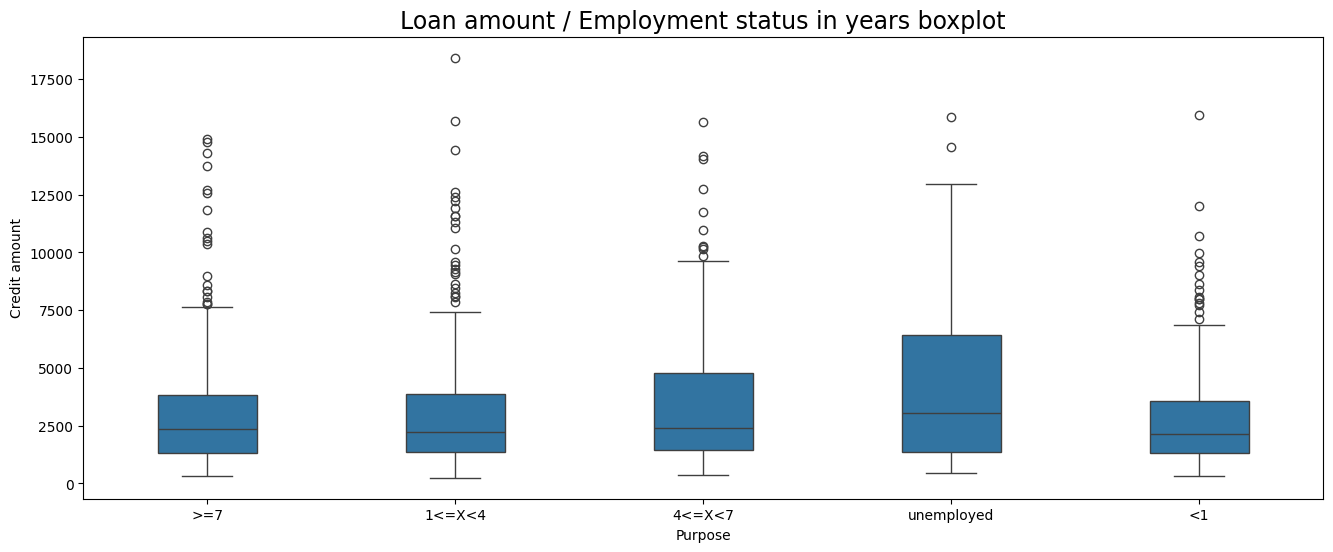



The mean credit amount take it for people with employment status 1<=X<4 was : 3125.29
The min credit amount take it for people with employment status 1<=X<4 was : 250.0
The max credit amount take it for people with employment status 1<=X<4 was : 18424.0


The mean credit amount take it for people with employment status 4<=X<7 was : 3601.7
The min credit amount take it for people with employment status 4<=X<7 was : 385.0
The max credit amount take it for people with employment status 4<=X<7 was : 15653.0


The mean credit amount take it for people with employment status <1 was : 2952.45
The min credit amount take it for people with employment status <1 was : 343.0
The max credit amount take it for people with employment status <1 was : 15945.0


The mean credit amount take it for people with employment status >=7 was : 3224.62
The min credit amount take it for people with employment status >=7 was : 338.0
The max credit amount take it for people with employment status >=7 was : 14896.

employment,1<=X<4,4<=X<7,<1,>=7,unemployed
count,339.0,174.0,172.0,253.0,62.0
mean,3125.29,3601.7,2952.45,3224.62,4216.76
std,2687.82,3025.7,2498.49,2809.15,3572.42
min,250.0,385.0,343.0,338.0,433.0
25%,1377.5,1450.5,1335.5,1300.0,1357.5
50%,2235.0,2386.0,2139.0,2337.0,3044.0
75%,3884.0,4783.75,3572.25,3832.0,6429.5
max,18424.0,15653.0,15945.0,14896.0,15857.0


In [18]:
# Groupping by employment and describing credit amount
df4 = df.groupby('employment')['credit_amount'].describe().round(2).T
df4 = df4.astype(str)
df4

# credit amount / employment Boxplot
plt.figure(figsize=(16,6))
sns.boxplot(data=df,y='credit_amount',width=0.4, orient='v', x='employment')
plt.title('Loan amount / Employment status in years boxplot',fontdict={'fontsize':'17'}, loc='center')
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.show()

# Printing the mean, min & max credit amount taken per employment status
print('\n')
for i in range(5):
    print('The mean credit amount take it for people with employment status '+ df4.columns[i] +' was : '+df4.iloc[1,i])
    print('The min credit amount take it for people with employment status '+ df4.columns[i] +' was : '+df4.iloc[3,i])
    print('The max credit amount take it for people with employment status '+ df4.columns[i] +' was : '+df4.iloc[-1,i])
    print('\n')

# Central measure variable of credit amount agaisnt employment status. Min, Max, Mean, Count, std, Q1, Q3
df4

-----

### Question / Task 4.2: Check the purpose of each group of employment status and see what were they getting a loan for and see if there is a relation between them

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of 1<=X<4 is "radio/tv" 



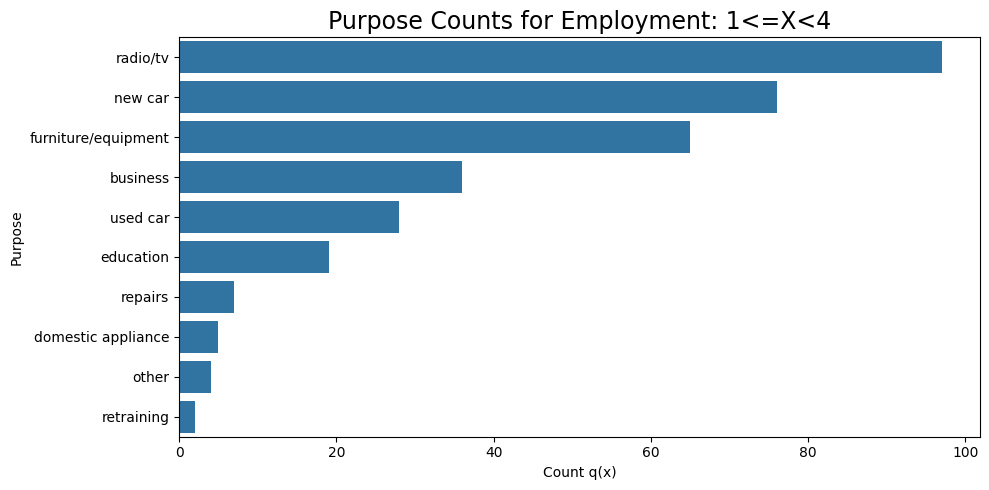

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of 4<=X<7 is "radio/tv" 



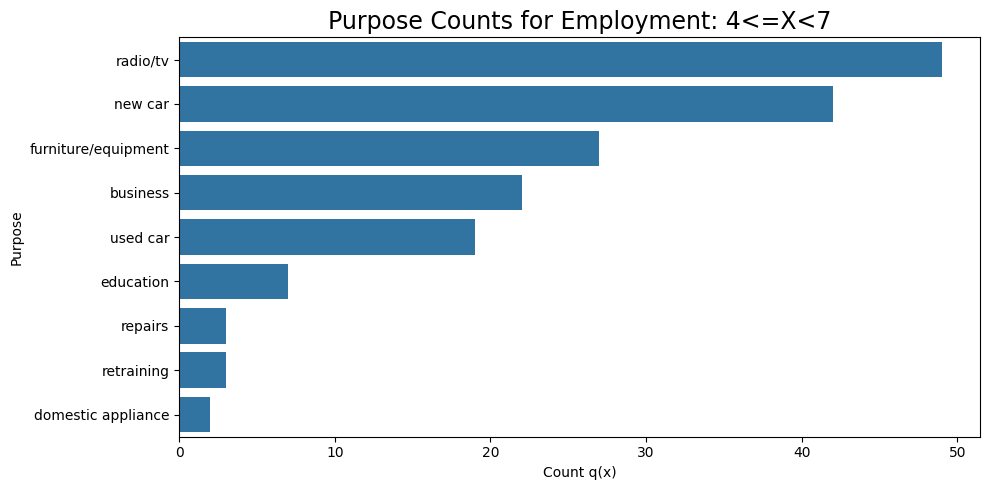

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of <1 is "radio/tv" 



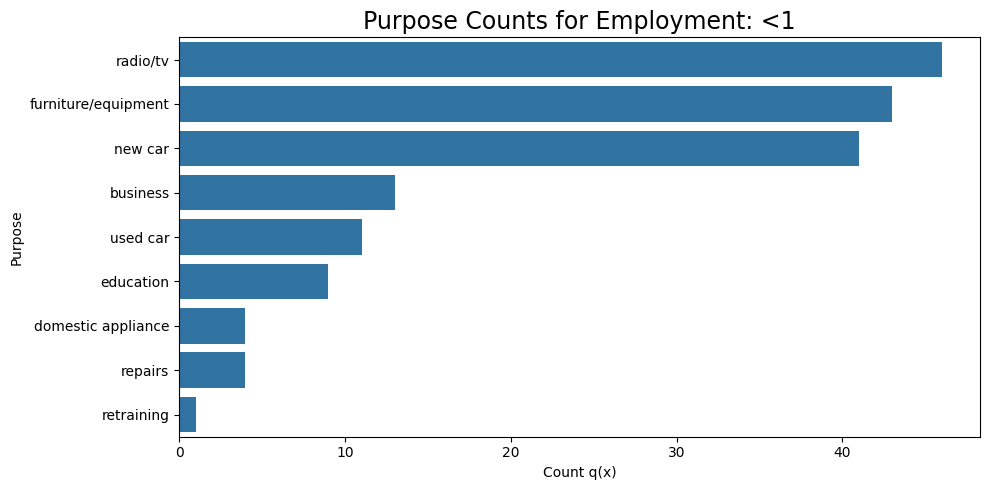

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of >=7 is "radio/tv" 



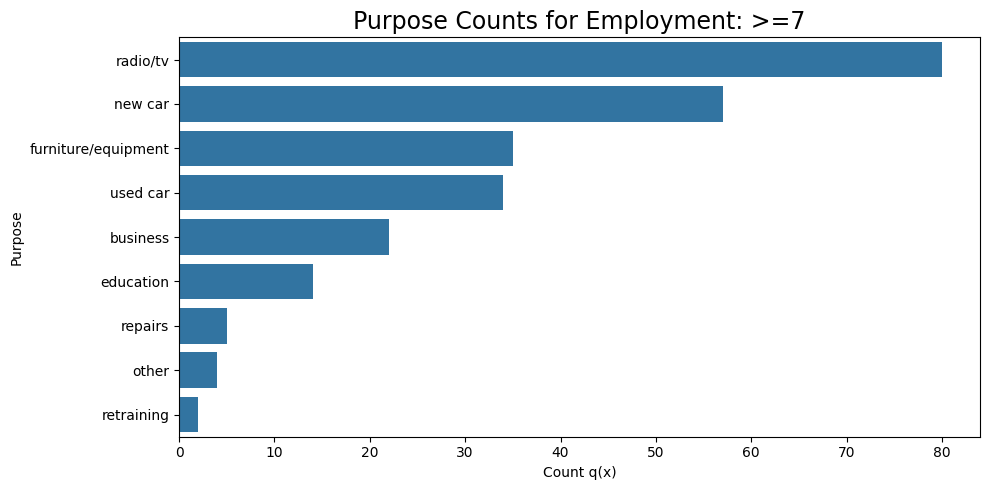

Axes(0.125,0.11;0.775x0.77) 
The top porpuse for status employment of unemployed is "new car" 



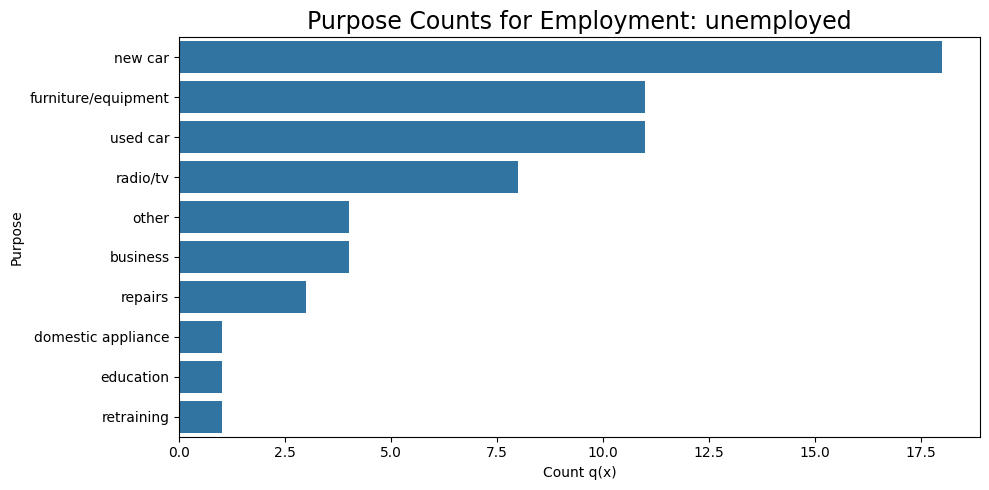

In [19]:
# Counting values and indexing them by employment and purpose and reseting the index
df4 = df[['employment','purpose']].value_counts().sort_index()
df4 = df4.reset_index()
df4.head()

# Getting the unique values from the column employment
employment_categories = df4['employment'].unique()

# Plotting a countplot regarding job status and purpose for each group and printing the top purpose for each group.
for category in employment_categories:
    plt.figure(figsize=(10, 5))  
    
    subset = df4[df4['employment'] == category]
    subset.sort_values(by='count', ascending=False, inplace=True)
    
    print(sns.barplot(data=subset, y='purpose', x='count',orient='h'),
          f'\nThe top porpuse for status employment of {category} is "{subset.iloc[0,1]}" \n')
    
    plt.title(f'Purpose Counts for Employment: {category}',fontdict={'fontsize':'17'}, loc='center')
    plt.ylabel('Purpose')
    plt.xlabel('Count q(x)')
    plt.tight_layout() 
    plt.show()

In [20]:
----

SyntaxError: invalid syntax (2133496677.py, line 1)

-----

### Task / Question 5: Check frequencies of loans regarding "Kind of job" variable and it's relationship between agaist loan duration

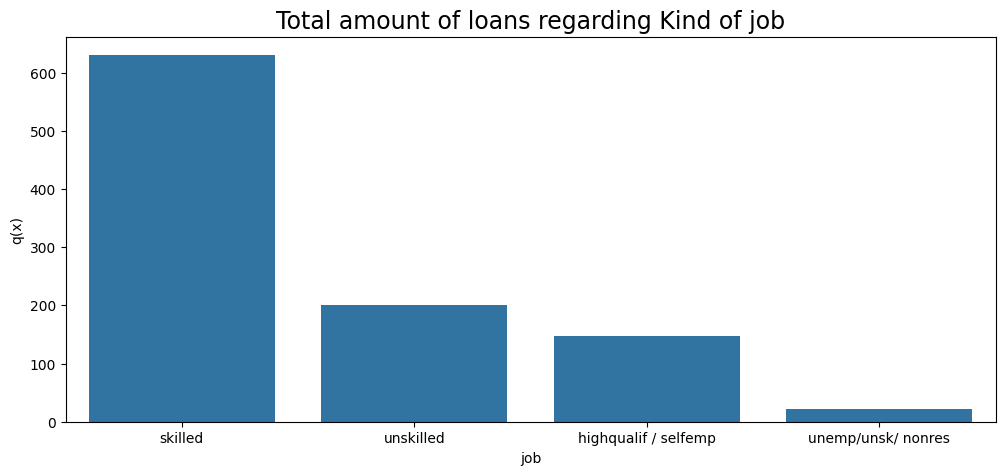



The workers with a kind of job skilled requested 630 loans and they represent the 63.0%
The workers with a kind of job unskilled requested 200 loans and they represent the 20.0%
The workers with a kind of job highqualif / selfemp requested 148 loans and they represent the 14.8%
The workers with a kind of job unemp/unsk/ nonres requested 22 loans and they represent the 2.2%


,duration,Weight
job,,
skilled,630,63.0
unskilled,200,20.0
highqualif / selfemp,148,14.8
unemp/unsk/ nonres,22,2.2


In [21]:
# Groupping by job and getting the frequencies for each kind of job the loan seekers have 
df6 = df.groupby('job')['duration'].count().sort_values(ascending=False).to_frame()
df6['Weight'] = round((df6['duration']/ df6['duration'].sum()*100),2)

# Plotting a barplot regarding frequencies of "Kind of job"
plt.figure(figsize=(12,5))
sns.barplot(x=df6.index,y=df6['duration'])
plt.title('Total amount of loans regarding Kind of job', fontdict={'fontsize':'17'}, loc='center')
plt.ylabel('q(x)')
plt.show()

print('\n')

# Printing the total requested loan for each group and their weight in the dataset
for i in range(len(df6['duration'])):
    print(f'The workers with a kind of job {df6.index[i]} requested {df6.iloc[i,0]} loans and they represent the {df6.iloc[i,1]}%')
df6


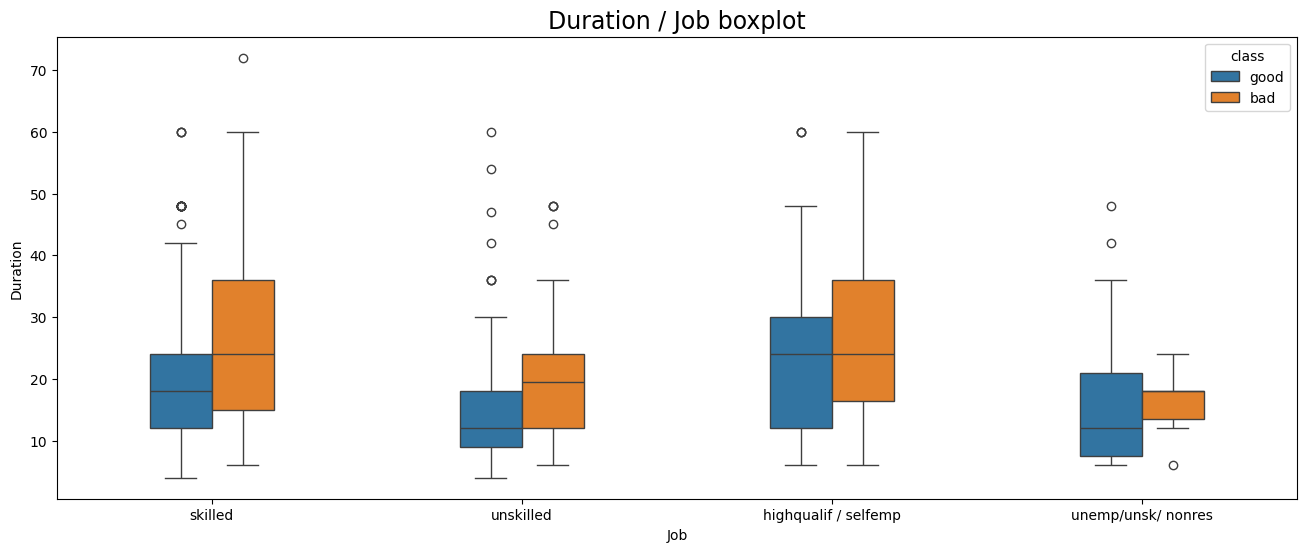



The count loan duration for highqualif / selfemp was 148.0
The count loan duration for skilled was 630.0
The count loan duration for unemp/unsk/ nonres was 22.0
The count loan duration for unskilled was 200.0

The mean loan duration for highqualif / selfemp was 25.17
The mean loan duration for skilled was 21.41
The mean loan duration for unemp/unsk/ nonres was 17.36
The mean loan duration for unskilled was 16.54

The std loan duration for highqualif / selfemp was 13.41
The std loan duration for skilled was 11.92
The std loan duration for unemp/unsk/ nonres was 11.59
The std loan duration for unskilled was 9.94

The min loan duration for highqualif / selfemp was 6.0
The min loan duration for skilled was 4.0
The min loan duration for unemp/unsk/ nonres was 6.0
The min loan duration for unskilled was 4.0

The 25% loan duration for highqualif / selfemp was 14.75
The 25% loan duration for skilled was 12.0
The 25% loan duration for unemp/unsk/ nonres was 9.75
The 25% loan duration for unsk

In [22]:
# Creating a dataframe that contains duration and job
df_skilled = df[['duration','job','class']]

# Plotting a box plot regarding job and loan duration
plt.figure(figsize=(16,6))
sns.boxplot(data=df_skilled,x='job',y='duration', width=0.4,hue='class')
plt.xlabel('Job')
plt.ylabel('Duration')
plt.title('Duration / Job boxplot',fontdict={'fontsize':'17'}, loc='center')
plt.show()

print('\n')
# Getting measures of central tendencies about duration agaisnt job and printing mean, min, max, Q1 & Q3
df_skilled = df_skilled.groupby('job')['duration'].describe().round(2)
df_skilled

for i in range(df_skilled.shape[1]):
    print(f'The {df_skilled.columns[i]} loan duration for {df_skilled.index[0]} was {df_skilled.iloc[0,i]}')
    print(f'The {df_skilled.columns[i]} loan duration for {df_skilled.index[1]} was {df_skilled.iloc[1,i]}')
    print(f'The {df_skilled.columns[i]} loan duration for {df_skilled.index[2]} was {df_skilled.iloc[2,i]}')
    print(f'The {df_skilled.columns[i]} loan duration for {df_skilled.index[3]} was {df_skilled.iloc[3,i]}\n')

Axes(0.125,0.11;0.775x0.77)


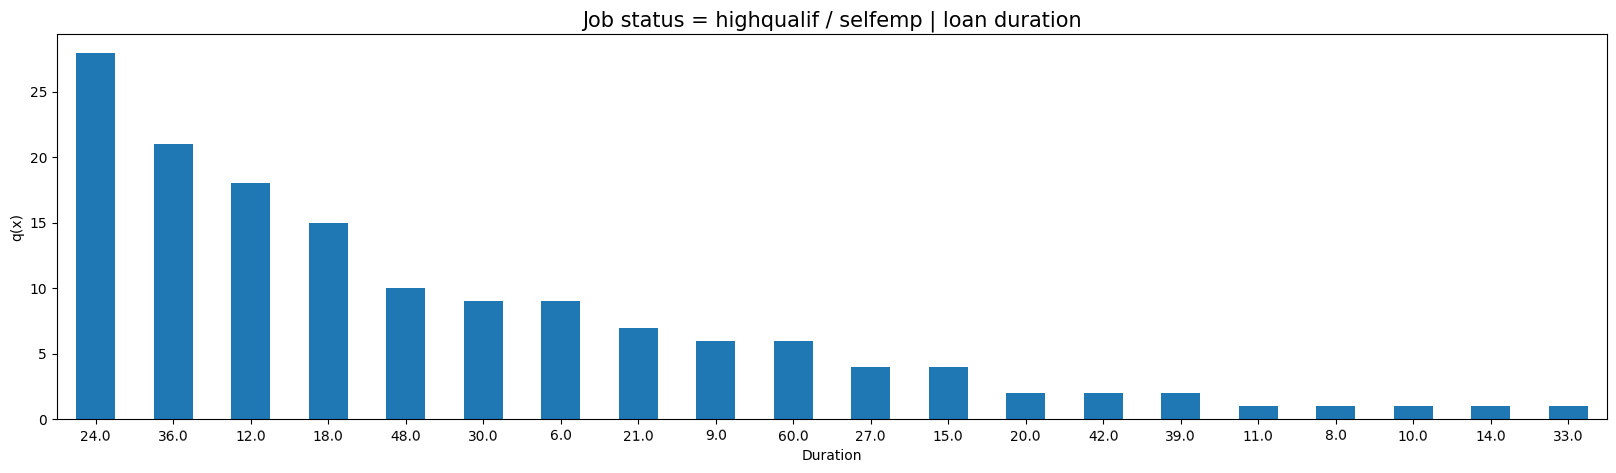

Axes(0.125,0.11;0.775x0.77)


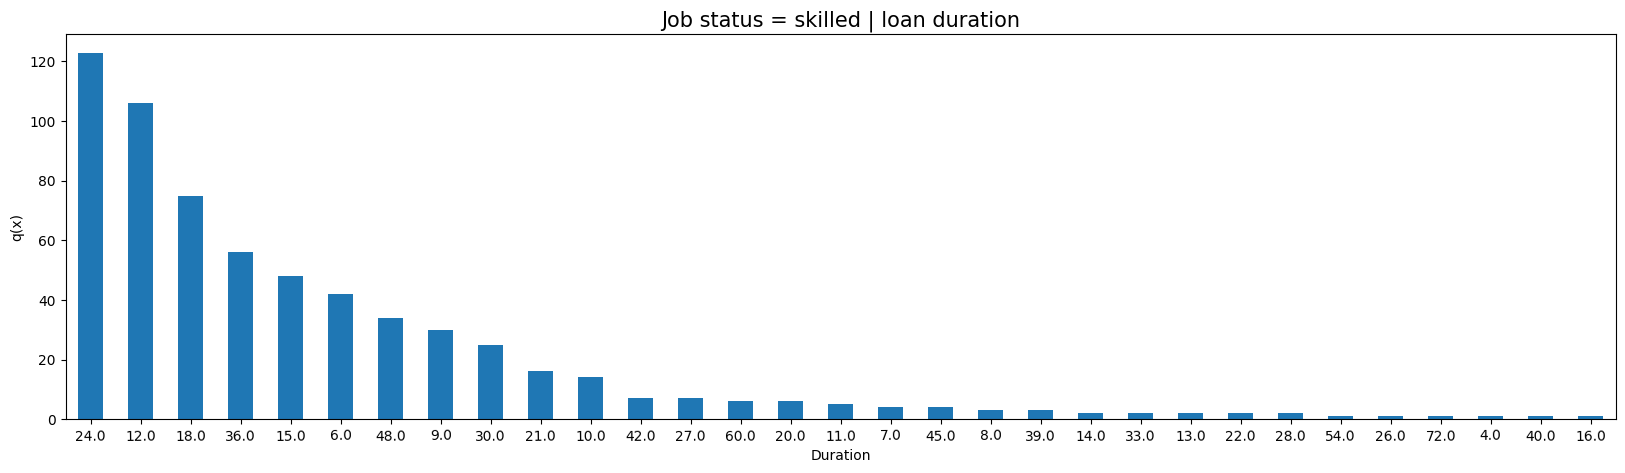

Axes(0.125,0.11;0.775x0.77)


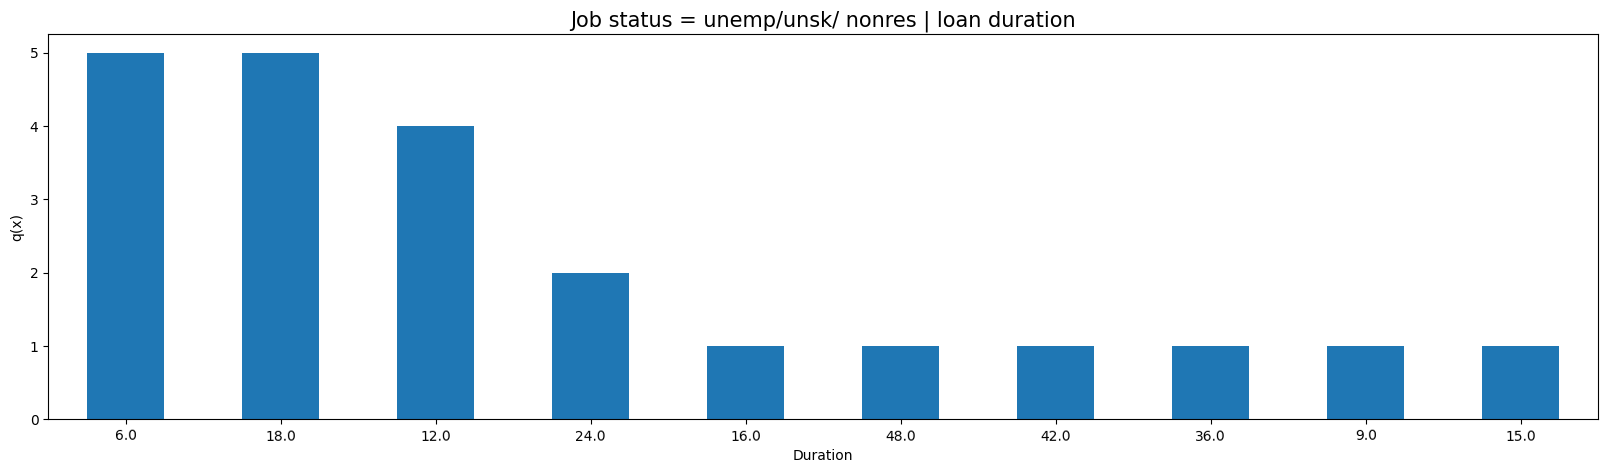

Axes(0.125,0.11;0.775x0.77)


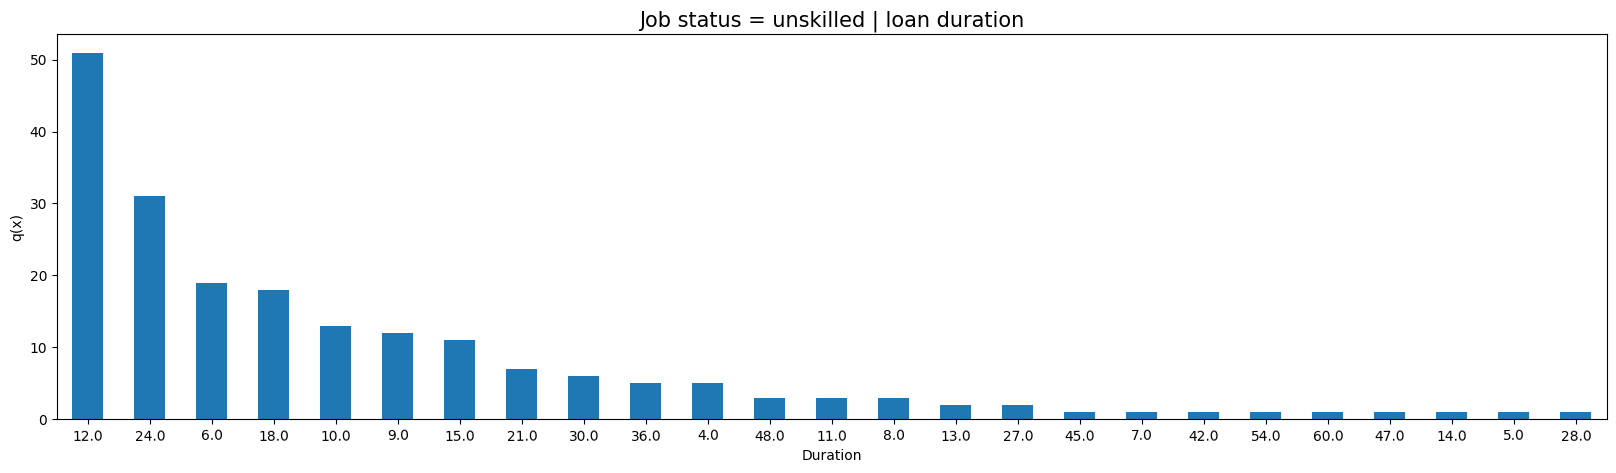

In [23]:
df_skilled = df
for i in np.unique(df['job']):
    df_skilled = df_skilled[['duration','job']]
    sub = df_skilled[df_skilled['job'] == i].value_counts()
    sub = sub.reset_index()
    print(sub.plot(kind='bar',x='duration',figsize=(20,5),rot=1,legend=None))
    
    plt.title(f'Job status = {i} | loan duration',fontdict={'fontsize':'15'})
    plt.xlabel('Duration')
    plt.ylabel('q(x)')
    plt.show()

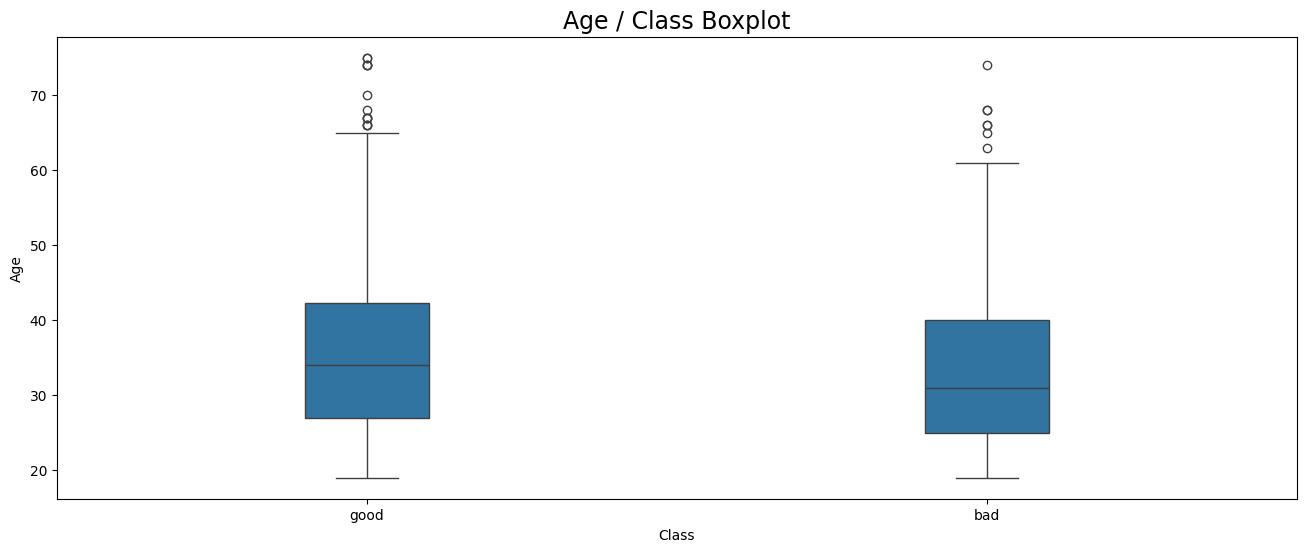

The bad class count age is 300.0
The good class count age is 700.0


The bad class mean age is 33.96
The good class mean age is 36.22


The bad class std age is 11.22
The good class std age is 11.38


The bad class min age is 19.0
The good class min age is 19.0


The bad class 25% age is 25.0
The good class 25% age is 27.0


The bad class 50% age is 31.0
The good class 50% age is 34.0


The bad class 75% age is 40.0
The good class 75% age is 42.25


The bad class max age is 74.0
The good class max age is 75.0




class,bad,good
count,300.00,700.00
mean,33.96,36.22
std,11.22,11.38
min,19.00,19.00
25%,25.00,27.00
50%,31.00,34.00
75%,40.00,42.25
max,74.00,75.00


In [24]:
# Age / class Boxplot
plt.figure(figsize=(16,6))
sns.boxplot(data=df[['class','age']], x='class',y='age', width =0.2)
plt.xlabel('Class')
plt.ylabel('Age')
plt.title('Age / Class Boxplot',fontdict={'fontsize':'17'}, loc='center')
plt.show()

# Groupping by class, describing age and printing info 
df_class = df.groupby('class')['age'].describe().T.round(2)

for i in range(len(df_class['good'])):
    print(f'The {df_class.columns[0]} class {df_class.index[i]} age is {df_class.iloc[i,0]}')
    print(f'The {df_class.columns[1]} class {df_class.index[i]} age is {df_class.iloc[i,1]}')
    print('\n')
df_class


### Question / Task 7: Check which group of worker took most loans and their variables¶


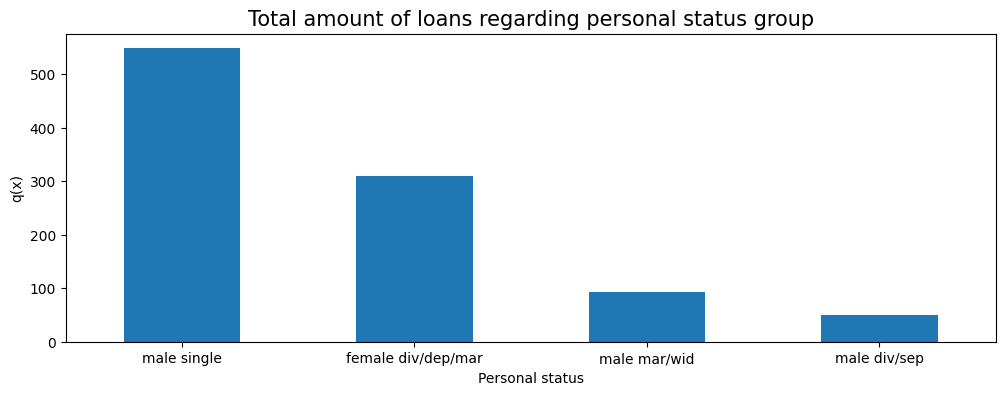


The male single group took 548 loans and they represent the 54.8% of the total amount of loans.

The female div/dep/mar group took 310 loans and they represent the 31.0% of the total amount of loans.

The male mar/wid group took 92 loans and they represent the 9.2% of the total amount of loans.

The male div/sep group took 50 loans and they represent the 5.0% of the total amount of loans.




,count,Weight
personal_status,,
male single,548,54.8
female div/dep/mar,310,31.0
male mar/wid,92,9.2
male div/sep,50,5.0


In [25]:
# groupping by personal status and counting them
df_personal_status = df['personal_status'].value_counts().sort_values(ascending=False).to_frame()
df_personal_status['Weight'] = round((df_personal_status['count']/df_personal_status['count'].sum())*100,2)
df_personal_status

df_personal_status.plot(kind='bar',y='count' , rot=0,figsize=(12,4), legend=None)
plt.title('Total amount of loans regarding personal status group', fontdict={'fontsize':'15'})
plt.xlabel('Personal status')
plt.ylabel('q(x)')
plt.show()


for i in range(len(df_personal_status['count'])):
        print(f'\nThe {df_personal_status.index[i]} group took {df_personal_status.iloc[i,0]} loans and they represent the {df_personal_status.iloc[i,1]}% of the total amount of loans.')
print('\n')
df_personal_status
